# Pipeline B — Classification trên SAM Crops
EfficientNetB0 | T4 15.9GB | mixed_float16 | Food-101 15 class

**Cấu trúc:**
- Cell 1: Setup & config
- Cell 2: Load SAM crops từ `/kaggle/input/`
- Cell 3: Model B1 — Không fine-tune → đánh giá + ví dụ pass/fail
- Cell 4: Model B2 — Fine-tune → đánh giá + ví dụ pass/fail
- Cell 5: So sánh B1 vs B2
- Cell 6: Inference pipeline (bbox + classify) — nền cho GUI

In [ ]:
# ── Cell 1: Setup ──────────────────────────────────────────────────────────
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

mixed_precision.set_global_policy('mixed_float16')
print('Policy:', mixed_precision.global_policy())
print('GPU:', tf.config.list_physical_devices('GPU'))

SELECTED_CLASSES = [
    'pizza', 'hamburger', 'french_fries', 'ice_cream', 'chocolate_cake',
    'sushi', 'ramen', 'fried_rice', 'omelette', 'pancakes',
    'hot_dog', 'grilled_salmon', 'caesar_salad', 'donuts', 'dumplings',
]
NUM_CLASSES = len(SELECTED_CLASSES)
IMG_SIZE    = 224
BATCH_SIZE  = 32
AUTOTUNE    = tf.data.AUTOTUNE

CROPS_DIR  = Path('/kaggle/input/datasets/qa9999/crops15/crops')
OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'Classes: {NUM_CLASSES}')
print(f'Crops dir exists: {CROPS_DIR.exists()}')

2026-05-23 03:16:20.115748: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779506180.294556      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779506180.350680      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779506180.776733      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779506180.776767      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779506180.776770      57 computation_placer.cc:177] computation placer alr

Policy: <DTypePolicy "mixed_float16">
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Classes: 15
Crops dir exists: True


In [ ]:
# ── Cell 2: Load SAM crops → tf.data pipeline ─────────────────────────────
def collect_image_paths(crops_dir: Path, classes: list):
    """Thu thập paths + labels từ thư mục crops/."""
    paths, labels = [], []
    class2idx = {c: i for i, c in enumerate(classes)}
    for cls in classes:
        cls_dir = crops_dir / cls
        if not cls_dir.exists():
            print(f'[WARN] Missing: {cls_dir}')
            continue
        imgs = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png'))
        paths.extend([str(p) for p in imgs])
        labels.extend([class2idx[cls]] * len(imgs))
    print(f'Total images: {len(paths)}')
    return np.array(paths), np.array(labels, dtype=np.int32)

all_paths, all_labels = collect_image_paths(CROPS_DIR, SELECTED_CLASSES)

# Train/test split 80/20 stratified
from sklearn.model_selection import train_test_split
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)
print(f'Train: {len(train_paths)} | Test: {len(test_paths)}')

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='augmentation')

def make_dataset(paths, labels, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, augment=True)
test_ds  = make_dataset(test_paths,  test_labels,  augment=False)
print('Datasets ready.')

Total images: 15000
Train: 12000 | Test: 3000


I0000 00:00:1779506204.610299      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779506204.616502      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets ready.


In [ ]:
# ── Cell 3: Model B1 — Không fine-tune (feature extraction only) ───────────

def build_model(trainable_base=False, unfreeze_last_n=0):
    """Xây model y hệt Pipeline A. Augmentation nằm trong model để tránh shape conflict."""
    # Augmentation định nghĩa trong model — fix lỗi shape khi dùng Keras 3
    aug = tf.keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ], name='augmentation')

    base = tf.keras.applications.EfficientNetB0(
        include_top=False, weights='imagenet'
    )
    base.trainable = False
    if trainable_base and unfreeze_last_n > 0:
        base.trainable = True
        for layer in base.layers[:-unfreeze_last_n]:
            layer.trainable = False

    inputs  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = aug(inputs)
    x       = base(x, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dropout(0.2)(x)
    outputs = layers.Dense(
        NUM_CLASSES, activation='softmax', dtype=tf.float32
    )(x)
    return tf.keras.Model(inputs, outputs)


# ── B1: Head-only training ──────────────────────────────────────────────────
model_b1 = build_model(trainable_base=False)
model_b1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(1e-3),
    metrics=['accuracy']
)
model_b1.summary(line_length=80)

callbacks_b1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=2, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        str(OUTPUT_DIR / 'model_b1_best.keras'), save_best_only=True
    ),
]

t0 = time.time()
history_b1 = model_b1.fit(
    train_ds, epochs=5,
    validation_data=test_ds,
    callbacks=callbacks_b1
)
print(f'B1 training time: {(time.time()-t0)/60:.1f} min')

loss_b1, acc_b1 = model_b1.evaluate(test_ds, verbose=0)
print(f'\n[B1] Test Loss: {loss_b1:.4f} | Test Accuracy: {acc_b1*100:.2f}%')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ augmentation (Sequential)         │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)       │ (None, 7, 7, 1280)       │     4,049,571 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 1280)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 15)               │        19,215 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 4,068,786 (15.52 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/5


I0000 00:00:1779506221.991766     151 cuda_dnn.cc:529] Loaded cuDNN version 91002


375/375 ━━━━━━━━━━━━━━━━━━━━ 160s 345ms/step - accuracy: 0.4758 - loss: 1.7774 - val_accuracy: 0.7013 - val_loss: 1.0322 - learning_rate: 0.0010
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 105s 279ms/step - accuracy: 0.6892 - loss: 1.0398 - val_accuracy: 0.7250 - val_loss: 0.9354 - learning_rate: 0.0010
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 105s 279ms/step - accuracy: 0.7194 - loss: 0.9406 - val_accuracy: 0.7347 - val_loss: 0.9033 - learning_rate: 0.0010
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 105s 279ms/step - accuracy: 0.7341 - loss: 0.8910 - val_accuracy: 0.7450 - val_loss: 0.8926 - learning_rate: 0.0010
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 105s 280ms/step - accuracy: 0.7400 - loss: 0.8726 - val_accuracy: 0.7487 - val_loss: 0.8766 - learning_rate: 0.0010
B1 training time: 9.7 min

[B1] Test Loss: 0.8766 | Test Accuracy: 74.87%



── Classification Report B1 (không fine-tune) ──
                precision    recall  f1-score   support

         pizza     0.8520    0.8350    0.8434       200
     hamburger     0.8299    0.6100    0.7032       200
  french_fries     0.6917    0.8300    0.7545       200
     ice_cream     0.8150    0.7050    0.7560       200
chocolate_cake     0.6151    0.8950    0.7291       200
         sushi     0.7917    0.6650    0.7228       200
         ramen     0.8299    0.8050    0.8173       200
    fried_rice     0.7617    0.8150    0.7874       200
      omelette     0.6243    0.5900    0.6067       200
      pancakes     0.7192    0.7300    0.7246       200
       hot_dog     0.7979    0.7700    0.7837       200
grilled_salmon     0.5691    0.7000    0.6278       200
  caesar_salad     0.8448    0.7350    0.7861       200
        donuts     0.8115    0.7750    0.7928       200
     dumplings     0.8508    0.7700    0.8084       200

      accuracy                         0.7487      3

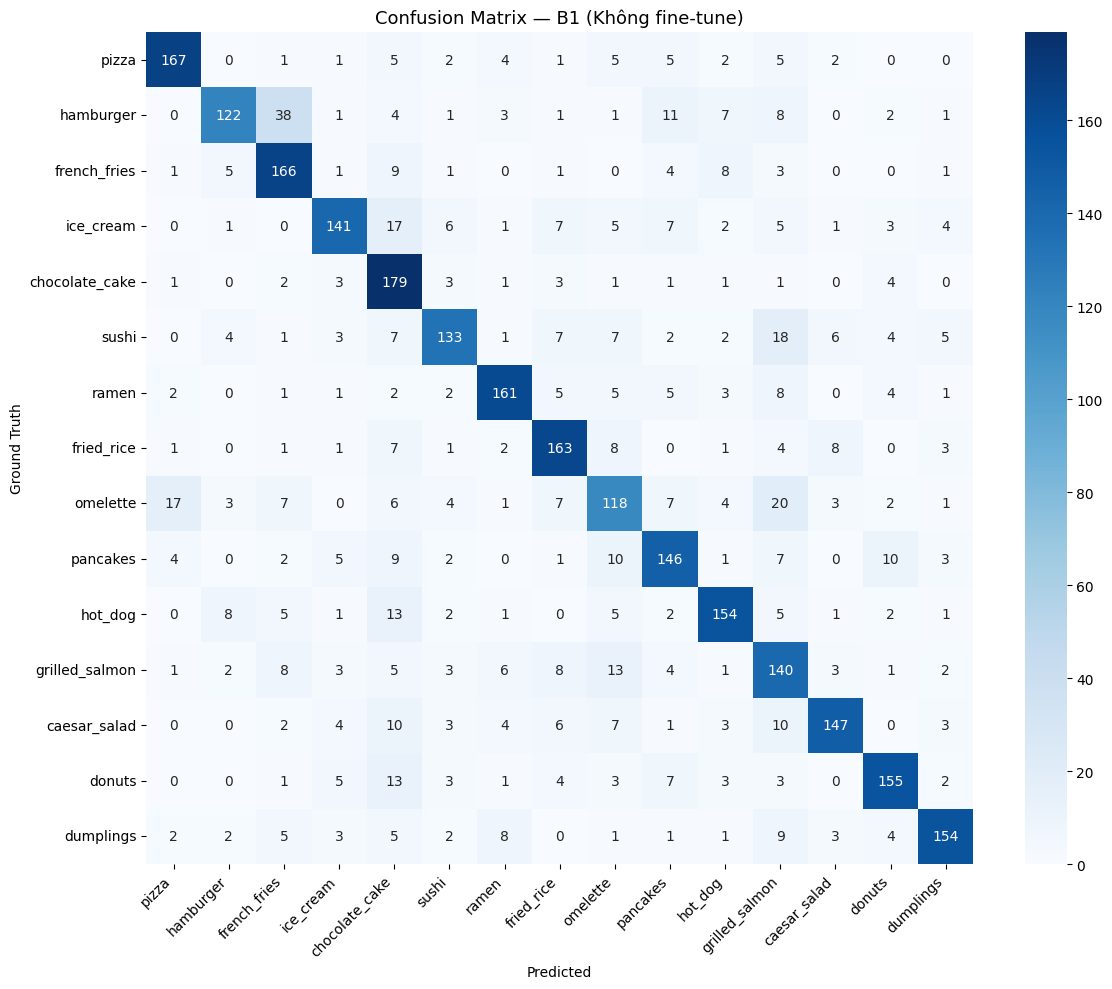

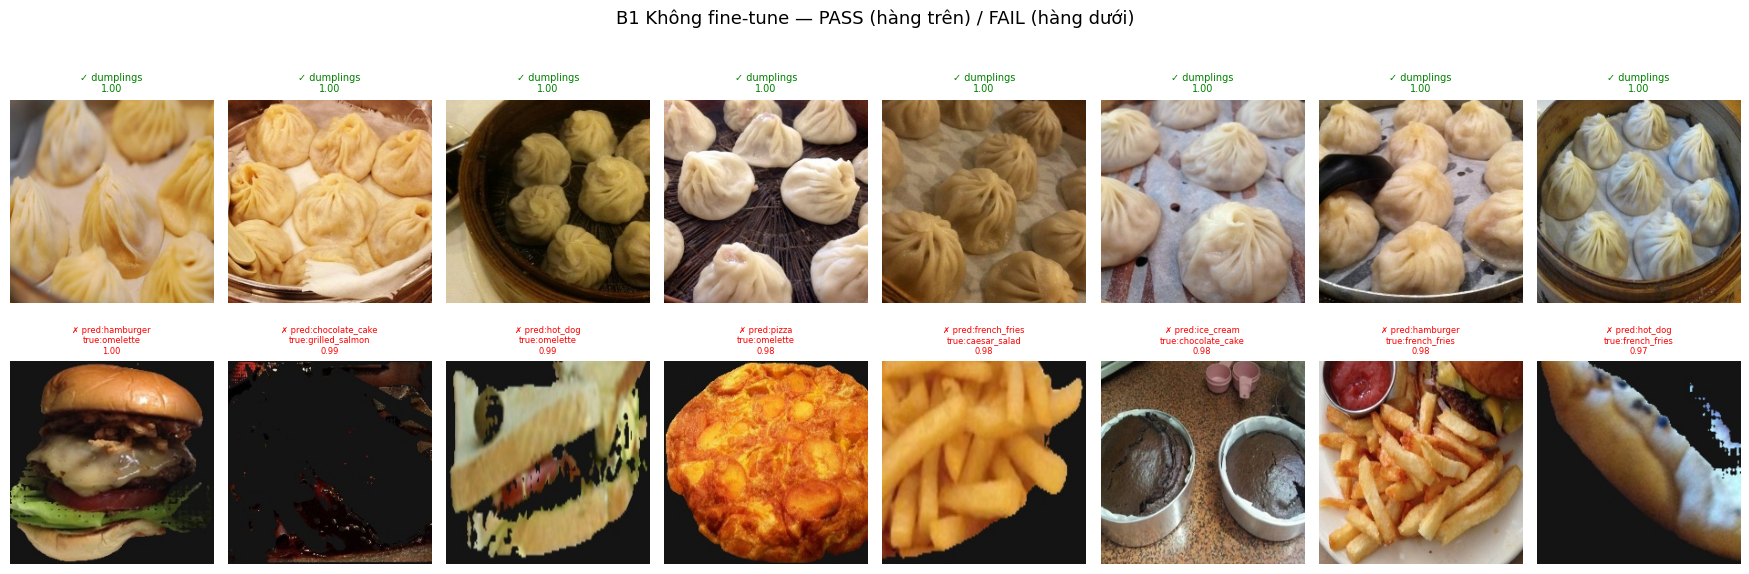


[B1 Không fine-tune] Accuracy: 74.87%
  PASS: 2246 | FAIL: 754
  Avg confidence PASS: 0.818
  Avg confidence FAIL: 0.504

Per-class accuracy (xếp từ thấp → cao):
         class   acc   n
      omelette 0.590 200
     hamburger 0.610 200
         sushi 0.665 200
grilled_salmon 0.700 200
     ice_cream 0.705 200
      pancakes 0.730 200
  caesar_salad 0.735 200
       hot_dog 0.770 200
     dumplings 0.770 200
        donuts 0.775 200
         ramen 0.805 200
    fried_rice 0.815 200
  french_fries 0.830 200
         pizza 0.835 200
chocolate_cake 0.895 200


In [ ]:
#Cell 3b: Đánh giá định lượng B1

def get_predictions(model, paths, labels, batch=64):
    """Lấy predicted class + confidence cho từng ảnh."""
    all_preds, all_confs = [], []
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(lambda p: tf.cast(
            tf.image.resize(tf.image.decode_jpeg(tf.io.read_file(p), channels=3),
                            [IMG_SIZE, IMG_SIZE]), tf.float32),
         num_parallel_calls=AUTOTUNE).batch(batch).prefetch(AUTOTUNE)
    for batch_imgs in ds:
        probs = model(batch_imgs, training=False).numpy()
        all_preds.extend(np.argmax(probs, axis=1))
        all_confs.extend(np.max(probs, axis=1))
    return np.array(all_preds), np.array(all_confs)

preds_b1, confs_b1 = get_predictions(model_b1, test_paths, test_labels)

# Classification report
print('\n── Classification Report B1 (không fine-tune) ──')
print(classification_report(
    test_labels, preds_b1,
    target_names=SELECTED_CLASSES, digits=4
))

# Confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(test_labels, preds_b1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SELECTED_CLASSES,
            yticklabels=SELECTED_CLASSES, ax=ax)
ax.set_title('Confusion Matrix — B1 (Không fine-tune)', fontsize=13)
ax.set_ylabel('Ground Truth'); ax.set_xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'b1_confusion_matrix.png', dpi=150)
plt.show()

# ── Ví dụ PASS / FAIL ────────────────────────────────────────────────────────
def show_pass_fail(paths, labels, preds, confs, model_name,
                   n_each=8, conf_thresh=0.5):
    correct_mask = (preds == labels)
    wrong_mask   = ~correct_mask

    # Lấy n_each ảnh pass (conf cao nhất) và fail (conf cao nhất trong wrong)
    pass_idx = np.where(correct_mask)[0]
    fail_idx = np.where(wrong_mask)[0]
    pass_idx = pass_idx[np.argsort(confs[pass_idx])[::-1][:n_each]]
    fail_idx = fail_idx[np.argsort(confs[fail_idx])[::-1][:n_each]]

    fig, axes = plt.subplots(2, n_each, figsize=(n_each * 2.2, 6))
    fig.suptitle(f'{model_name} — PASS (hàng trên) / FAIL (hàng dưới)',
                 fontsize=13, y=1.01)

    for col, idx in enumerate(pass_idx):
        img = np.array(Image.open(paths[idx]).resize((IMG_SIZE, IMG_SIZE)))
        axes[0, col].imshow(img)
        axes[0, col].set_title(
            f'✓ {SELECTED_CLASSES[preds[idx]]}\n{confs[idx]:.2f}',
            fontsize=7, color='green'
        )
        axes[0, col].axis('off')

    for col, idx in enumerate(fail_idx):
        img = np.array(Image.open(paths[idx]).resize((IMG_SIZE, IMG_SIZE)))
        axes[1, col].imshow(img)
        axes[1, col].set_title(
            f'✗ pred:{SELECTED_CLASSES[preds[idx]]}\ntrue:{SELECTED_CLASSES[labels[idx]]}\n{confs[idx]:.2f}',
            fontsize=6, color='red'
        )
        axes[1, col].axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{model_name.lower().replace(" ","_")}_pass_fail.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # In số liệu tóm tắt
    print(f'\n[{model_name}] Accuracy: {(preds==labels).mean()*100:.2f}%')
    print(f'  PASS: {correct_mask.sum()} | FAIL: {wrong_mask.sum()}')
    print(f'  Avg confidence PASS: {confs[correct_mask].mean():.3f}')
    print(f'  Avg confidence FAIL: {confs[wrong_mask].mean():.3f}')

    # Per-class accuracy
    per_class = []
    for i, cls in enumerate(SELECTED_CLASSES):
        mask = labels == i
        cls_acc = (preds[mask] == labels[mask]).mean() if mask.sum() > 0 else 0
        per_class.append({'class': cls, 'acc': cls_acc, 'n': mask.sum()})
    df = pd.DataFrame(per_class).sort_values('acc')
    print(f'\nPer-class accuracy (xếp từ thấp → cao):')
    print(df.to_string(index=False))

show_pass_fail(test_paths, test_labels, preds_b1, confs_b1, 'B1 Không fine-tune')

In [ ]:
# ── Cell 4: Model B2 — Fine-tune────────────────────────

# Load lại best checkpoint của B1 rồi unfreeze 30 layer cuối
model_b2 = tf.keras.models.load_model(OUTPUT_DIR / 'model_b1_best.keras')

# Tìm EfficientNetB0 base theo tên thay vì hardcode index
# → an toàn bất kể thứ tự layer thay đổi
base_layer = next(
    l for l in model_b2.layers
    if isinstance(l, tf.keras.Model) and 'efficientnet' in l.name.lower()
)
print(f'Base layer found: "{base_layer.name}" | Total sub-layers: {len(base_layer.layers)}')

# Unfreeze toàn bộ base trước, rồi đóng băng tất cả trừ 30 layer cuối
base_layer.trainable = True
for layer in base_layer.layers[:-30]:
    layer.trainable = False

frozen   = sum(1 for l in base_layer.layers if not l.trainable)
unfrozen = sum(1 for l in base_layer.layers if l.trainable)
print(f'Base sub-layers — frozen: {frozen} | unfrozen (trainable): {unfrozen}')

model_b2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(1e-5),   # lr nhỏ hơn 100x so với B1
    metrics=['accuracy']
)

trainable_params = sum(tf.size(w).numpy() for w in model_b2.trainable_weights)
print(f'Trainable params (B2): {trainable_params:,}')

callbacks_b2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=2, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        str(OUTPUT_DIR / 'model_b2_best.keras'), save_best_only=True
    ),
]

t0 = time.time()
history_b2 = model_b2.fit(
    train_ds, epochs=20,
    validation_data=test_ds,
    callbacks=callbacks_b2
)
print(f'B2 training time: {(time.time()-t0)/60:.1f} min')

loss_b2, acc_b2 = model_b2.evaluate(test_ds, verbose=0)
print(f'\n[B2] Test Loss: {loss_b2:.4f} | Test Accuracy: {acc_b2*100:.2f}%')

Base layer found: "efficientnetb0" | Total sub-layers: 238
Base sub-layers — frozen: 208 | unfrozen (trainable): 30
Trainable params (B2): 1,515,375
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 127s 278ms/step - accuracy: 0.6162 - loss: 1.2935 - val_accuracy: 0.7043 - val_loss: 1.0119 - learning_rate: 1.0000e-05
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 102s 272ms/step - accuracy: 0.6762 - loss: 1.1070 - val_accuracy: 0.7173 - val_loss: 0.9603 - learning_rate: 1.0000e-05
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 102s 272ms/step - accuracy: 0.6994 - loss: 1.0217 - val_accuracy: 0.7257 - val_loss: 0.9254 - learning_rate: 1.0000e-05
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 102s 272ms/step - accuracy: 0.7111 - loss: 0.9713 - val_accuracy: 0.7303 - val_loss: 0.9010 - learning_rate: 1.0000e-05
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 102s 272ms/step - accuracy: 0.7217 - loss: 0.9371 - val_accuracy: 0.7387 - val_loss: 0.8813 - learning_rate: 1.0000e-05
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 102s 272ms/


── Classification Report B2 (có fine-tune) ──
                precision    recall  f1-score   support

         pizza     0.8301    0.8550    0.8424       200
     hamburger     0.8170    0.6250    0.7082       200
  french_fries     0.6818    0.8250    0.7466       200
     ice_cream     0.7969    0.7650    0.7806       200
chocolate_cake     0.6953    0.8900    0.7807       200
         sushi     0.8352    0.7600    0.7958       200
         ramen     0.8367    0.8200    0.8283       200
    fried_rice     0.8191    0.7700    0.7938       200
      omelette     0.6212    0.6150    0.6181       200
      pancakes     0.8462    0.7150    0.7751       200
       hot_dog     0.7659    0.7850    0.7753       200
grilled_salmon     0.6398    0.6750    0.6569       200
  caesar_salad     0.8088    0.8250    0.8168       200
        donuts     0.7960    0.8000    0.7980       200
     dumplings     0.8173    0.8050    0.8111       200

      accuracy                         0.7687      3000

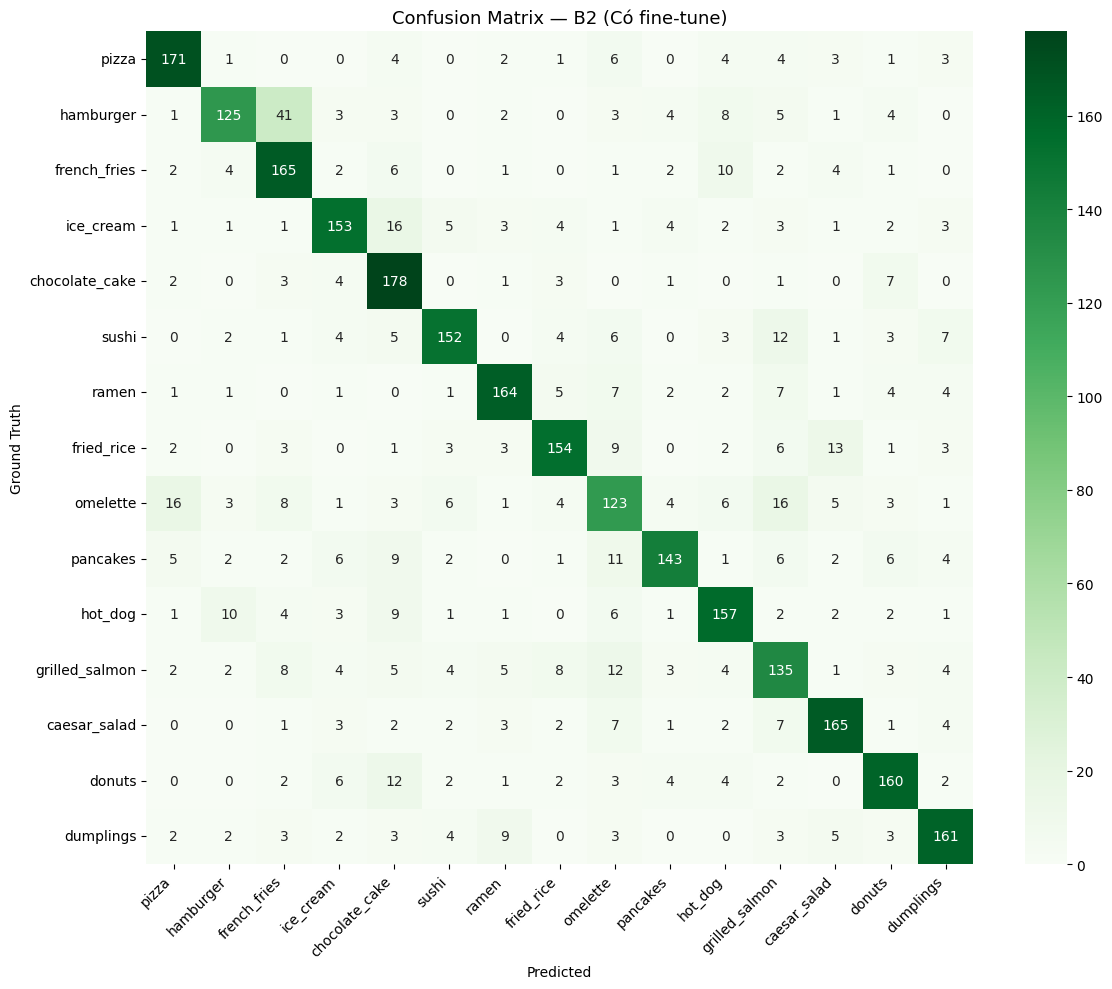

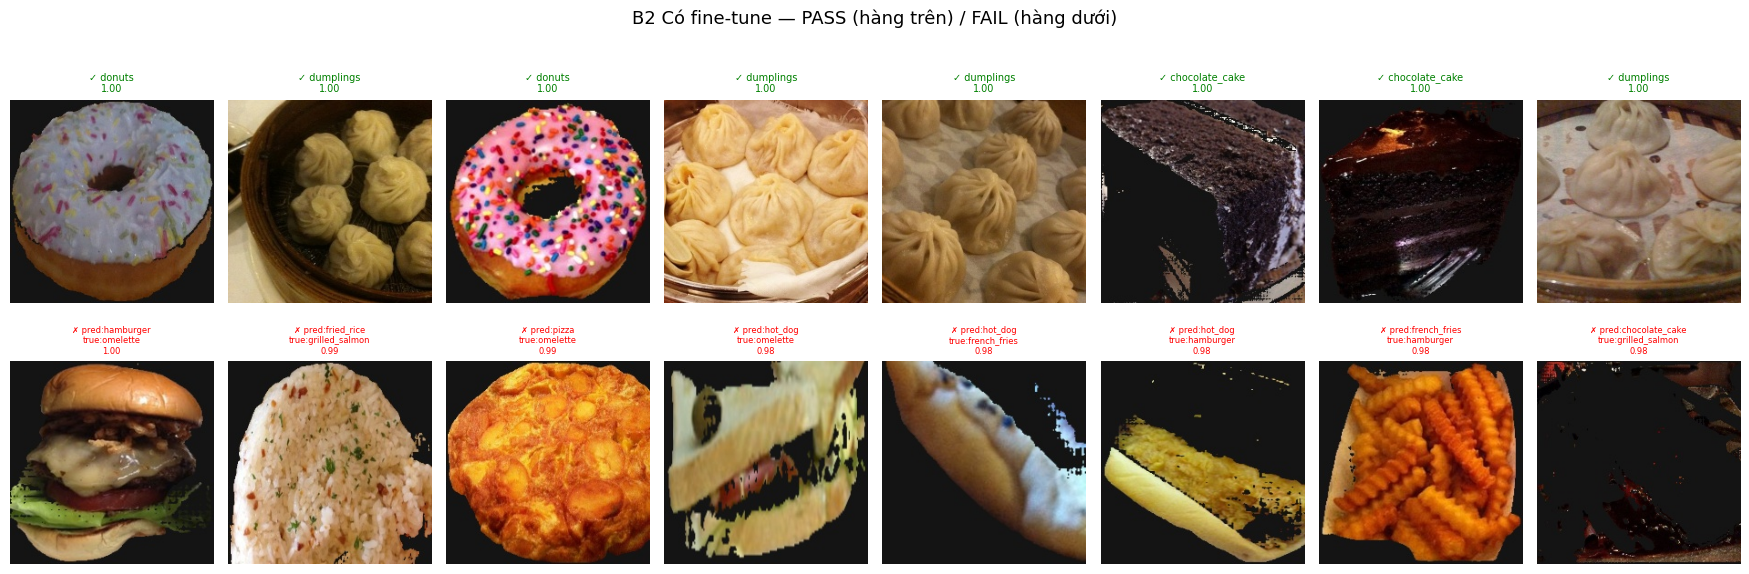


[B2 Có fine-tune] Accuracy: 76.87%
  PASS: 2306 | FAIL: 694
  Avg confidence PASS: 0.853
  Avg confidence FAIL: 0.510

Per-class accuracy (xếp từ thấp → cao):
         class   acc   n
      omelette 0.615 200
     hamburger 0.625 200
grilled_salmon 0.675 200
      pancakes 0.715 200
         sushi 0.760 200
     ice_cream 0.765 200
    fried_rice 0.770 200
       hot_dog 0.785 200
        donuts 0.800 200
     dumplings 0.805 200
         ramen 0.820 200
  french_fries 0.825 200
  caesar_salad 0.825 200
         pizza 0.855 200
chocolate_cake 0.890 200

Fine-tune cải thiện: 136 ảnh
Fine-tune làm tệ hơn: 76 ảnh


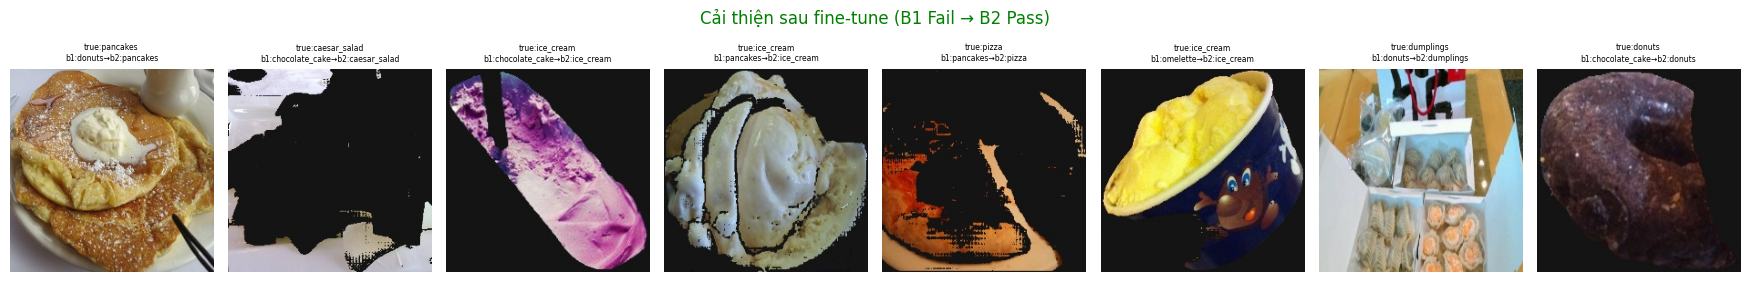

In [ ]:
# ── Cell 4b: Đánh giá định lượng B2 + ví dụ pass/fail ─────────────────────

preds_b2, confs_b2 = get_predictions(model_b2, test_paths, test_labels)

print('\n── Classification Report B2 (có fine-tune) ──')
print(classification_report(
    test_labels, preds_b2,
    target_names=SELECTED_CLASSES, digits=4
))

# Confusion matrix B2
fig, ax = plt.subplots(figsize=(12, 10))
cm2 = confusion_matrix(test_labels, preds_b2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=SELECTED_CLASSES,
            yticklabels=SELECTED_CLASSES, ax=ax)
ax.set_title('Confusion Matrix — B2 (Có fine-tune)', fontsize=13)
ax.set_ylabel('Ground Truth'); ax.set_xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'b2_confusion_matrix.png', dpi=150)
plt.show()

show_pass_fail(test_paths, test_labels, preds_b2, confs_b2, 'B2 Có fine-tune')

# ── Ảnh cải thiện sau fine-tune (B1 fail → B2 pass) ──────────────────────
improved_idx = np.where((preds_b1 != test_labels) & (preds_b2 == test_labels))[0]
degraded_idx = np.where((preds_b1 == test_labels) & (preds_b2 != test_labels))[0]
print(f'\nFine-tune cải thiện: {len(improved_idx)} ảnh')
print(f'Fine-tune làm tệ hơn: {len(degraded_idx)} ảnh')

if len(improved_idx) >= 4:
    n_show = min(8, len(improved_idx))
    fig, axes = plt.subplots(1, n_show, figsize=(n_show * 2.2, 3))
    fig.suptitle('Cải thiện sau fine-tune (B1 Fail → B2 Pass)', color='green')
    for col, idx in enumerate(improved_idx[:n_show]):
        img = np.array(Image.open(test_paths[idx]).resize((IMG_SIZE, IMG_SIZE)))
        axes[col].imshow(img)
        axes[col].set_title(
            f'true:{SELECTED_CLASSES[test_labels[idx]]}\nb1:{SELECTED_CLASSES[preds_b1[idx]]}→b2:{SELECTED_CLASSES[preds_b2[idx]]}',
            fontsize=5.5
        )
        axes[col].axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'b2_improvements.png', dpi=150, bbox_inches='tight')
    plt.show()

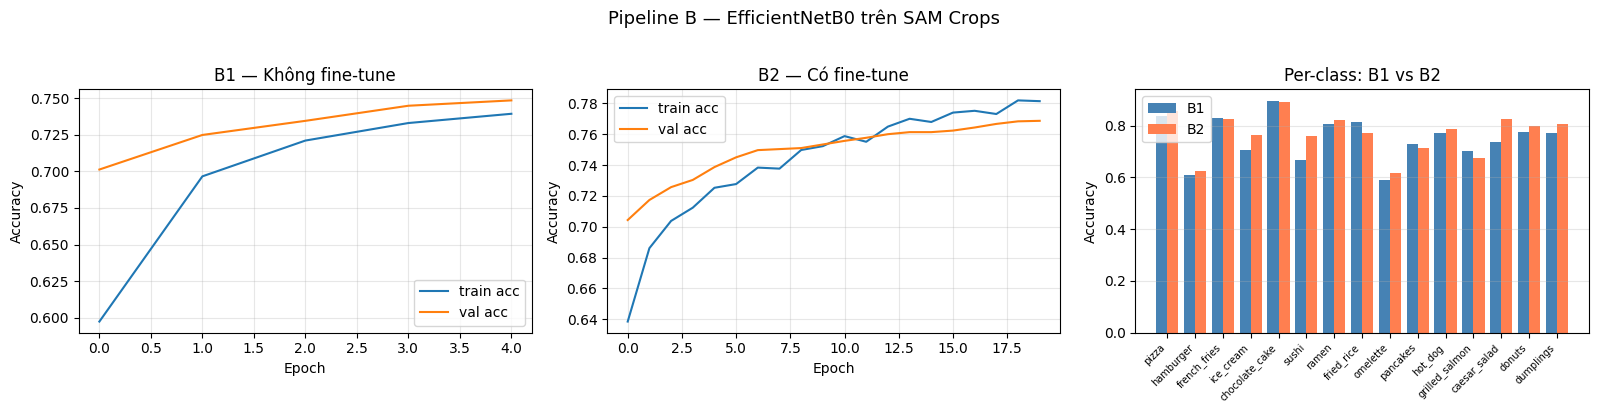


── Tổng hợp Pipeline B ──
            Model Accuracy   Loss
B1 (no fine-tune)   74.87% 0.8766
   B2 (fine-tune)   76.87% 0.7831


In [ ]:
# ── Cell 5: So sánh B1 vs B2 — learning curves + bar chart ────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 5a. Learning curves B1
ax = axes[0]
ax.plot(history_b1.history['accuracy'],    label='train acc')
ax.plot(history_b1.history['val_accuracy'],label='val acc')
ax.set_title('B1 — Không fine-tune'); ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy'); ax.legend(); ax.grid(alpha=0.3)

# 5b. Learning curves B2
ax = axes[1]
ax.plot(history_b2.history['accuracy'],    label='train acc')
ax.plot(history_b2.history['val_accuracy'],label='val acc')
ax.set_title('B2 — Có fine-tune'); ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy'); ax.legend(); ax.grid(alpha=0.3)

# 5c. Bar: B1 vs B2 per-class accuracy
ax = axes[2]
acc_b1_per = [(preds_b1[test_labels==i] == i).mean() for i in range(NUM_CLASSES)]
acc_b2_per = [(preds_b2[test_labels==i] == i).mean() for i in range(NUM_CLASSES)]
x = np.arange(NUM_CLASSES)
ax.bar(x - 0.2, acc_b1_per, 0.4, label='B1', color='steelblue')
ax.bar(x + 0.2, acc_b2_per, 0.4, label='B2', color='coral')
ax.set_xticks(x); ax.set_xticklabels(SELECTED_CLASSES, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Accuracy'); ax.set_title('Per-class: B1 vs B2')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Pipeline B — EfficientNetB0 trên SAM Crops', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'b_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Bảng tổng hợp
summary = pd.DataFrame({
    'Model':    ['B1 (no fine-tune)', 'B2 (fine-tune)'],
    'Accuracy': [f'{acc_b1*100:.2f}%', f'{acc_b2*100:.2f}%'],
    'Loss':     [f'{loss_b1:.4f}',     f'{loss_b2:.4f}'],
})
print('\n── Tổng hợp Pipeline B ──')
print(summary.to_string(index=False))